Import Libraries

In [383]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE

import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [384]:
df = pd.read_csv("Employee Attrition.csv")

In [385]:
df.info()   

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [386]:
df.shape

(1470, 35)

In [387]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [388]:
fillna_cols = df.select_dtypes(include=['float64', 'int64']).columns
imputer = SimpleImputer(strategy='median')

Remove Duplicates

In [389]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)


Dataset Shape After Removing Duplicates: (1470, 35)


In [390]:
drop_cols = [
    'EmployeeCount',
    'StandardHours',
    'Over18',
    'EmployeeNumber'
]

df = df.drop(columns=drop_cols)

Feature Engineering

In [391]:
df['OverTimeRisk'] = (
    (df['OverTime'] == 'Yes').astype(int) *
    df['DistanceFromHome']
)

In [392]:
df['SatisfactionIndex'] = (
    df['EnvironmentSatisfaction'] +
    df['JobSatisfaction'] 
)

In [393]:
df['StockOptionWeight'] = (
    df['StockOptionLevel'] * df['MonthlyIncome']    
)

In [394]:
df['ExperienceGap'] = (
    df['TotalWorkingYears'] -
    df['YearsAtCompany']
)

In [395]:
df['CareerStability'] = (
    df['YearsInCurrentRole'] /
    (df['YearsAtCompany'] + 1)
)

In [396]:
df['CareerGrowthRisk'] = (
    df['YearsSinceLastPromotion'] /
    (df['JobLevel'] + 1)
)

In [397]:
df['UnderPromotionRisk'] = (
    df['TotalWorkingYears'] /
    (df['JobLevel'] + 1)
)

In [398]:
df['BurnoutRisk'] =(
    df['JobLevel'] *
    df['OverTime'] *
    (df['DistanceFromHome'] + 1)
    )     

In [399]:
pd.get_dummies(df, drop_first=True)

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,BurnoutRisk_YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYes,BurnoutRisk_YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYes,BurnoutRisk_YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYes,BurnoutRisk_YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYes,BurnoutRisk_YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYes,BurnoutRisk_YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYes,BurnoutRisk_YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYes,BurnoutRisk_YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYes,BurnoutRisk_YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYes,BurnoutRisk_YesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYesYes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,False,False,False,False,False
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,False,False,False,False,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,False,False,False,False,False,False,False,False,False,False
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,False,False,False,False,False,False
4,27,591,2,1,1,40,3,1,2,3468,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,False,False,False,False,False,False,False,False,False,False
1466,39,613,6,1,4,42,2,3,1,9991,...,False,False,False,False,F

Encode categorial values

In [400]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
df.head()   

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,YearsSinceLastPromotion,YearsWithCurrManager,OverTimeRisk,SatisfactionIndex,StockOptionWeight,ExperienceGap,CareerStability,CareerGrowthRisk,UnderPromotionRisk,BurnoutRisk
0,41,1,2,1102,2,1,2,1,2,0,...,0,5,1,6,0,2,0.571429,0.000000,2.666667,75
1,49,0,1,279,1,8,1,1,3,1,...,1,7,0,5,5130,0,0.636364,0.333333,3.333333,16
2,37,1,2,1373,1,2,2,4,4,1,...,0,0,2,7,0,7,0.000000,0.000000,3.500000,74
3,33,0,1,1392,1,3,4,1,4,0,...,3,0,3,7,0,0,0.777778,1.500000,4.000000,75
4,27,0,2,591,1,2,1,3,1,1,...,2,2,0,3,3468,4,0.666667,1.000000,3.000000,1


In [401]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [402]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:")
print(pd.Series(y_resampled).value_counts())

After SMOTE:
Attrition
1    1233
0    1233
Name: count, dtype: int64


In [403]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_resampled)

In [404]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1972, 38)
(494, 38)


In [405]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(verbose=0)

In [406]:

if 'YearsAtCompany' in df.columns:
    df['ExperienceCategory'] = pd.cut(
        df['YearsAtCompany'],
        bins=[0, 3, 7, 15, 40],
        labels=['Junior', 'Mid', 'Senior', 'Expert']
    )

print(df.head())

   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EnvironmentSatisfaction  Gender  ...  \
0          2               1                        2       0  ...   
1          1               1                        3       1  ...   
2          2               4                        4       1  ...   
3          4               1                        4       0  ...   
4          1               3                        1       1  ...   

   YearsWithCurrManager  OverTimeRisk  SatisfactionIndex  StockOptionWeight  \
0                     5        

In [407]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

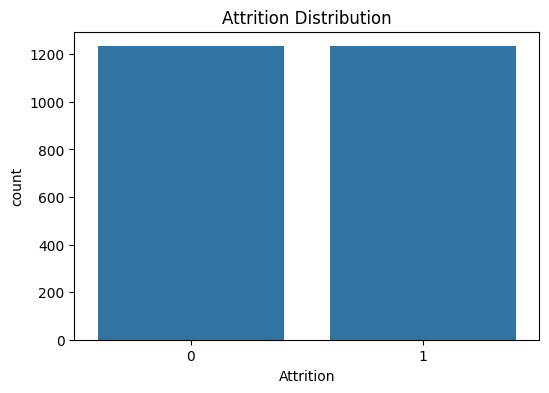

In [408]:
# Attrition Distribution

plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled)
plt.title('Attrition Distribution')
plt.show()


Machine Learning Models

In [409]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True),
    'XGBoost': XGBClassifier(eval_metric='logloss')
}


In [410]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:,1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = 0

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by='F1 Score', ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XGBoost,0.941296,0.942387,0.938525,0.940452,0.978721
2,Random Forest,0.925101,0.919028,0.930328,0.924644,0.977975
3,SVM,0.914980,0.927966,0.897541,0.912500,0.965656
1,Decision Tree,0.872470,0.854902,0.893443,0.873747,0.872721
0,Logistic Regression,0.864372,0.886463,0.831967,0.858351,0.936836


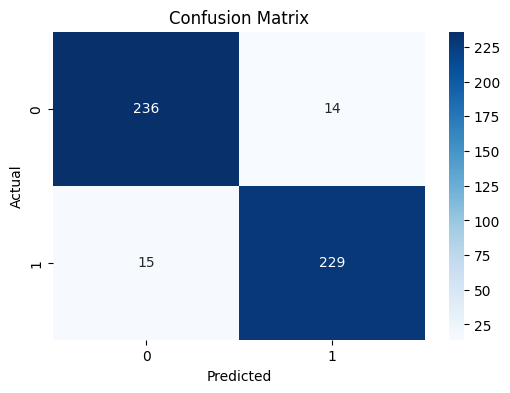

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       250
           1       0.94      0.94      0.94       244

    accuracy                           0.94       494
   macro avg       0.94      0.94      0.94       494
weighted avg       0.94      0.94      0.94       494



In [411]:
best_model = XGBClassifier(eval_metric='logloss')

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

print(classification_report(y_test, y_pred))


Explainable AI Module

Feature Importance 

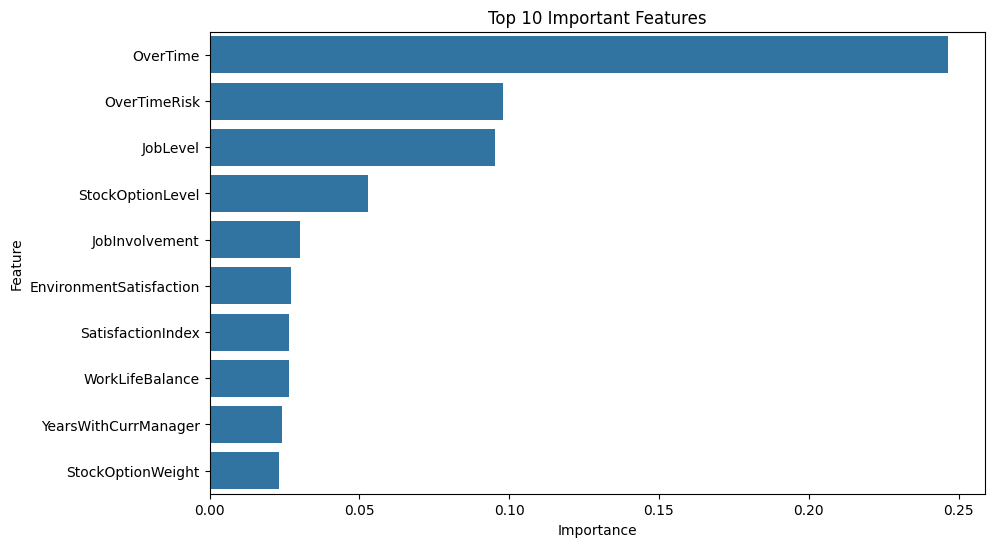

In [412]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance.head(10))

plt.title('Top 10 Important Features')

plt.show()

SHAP Explainability

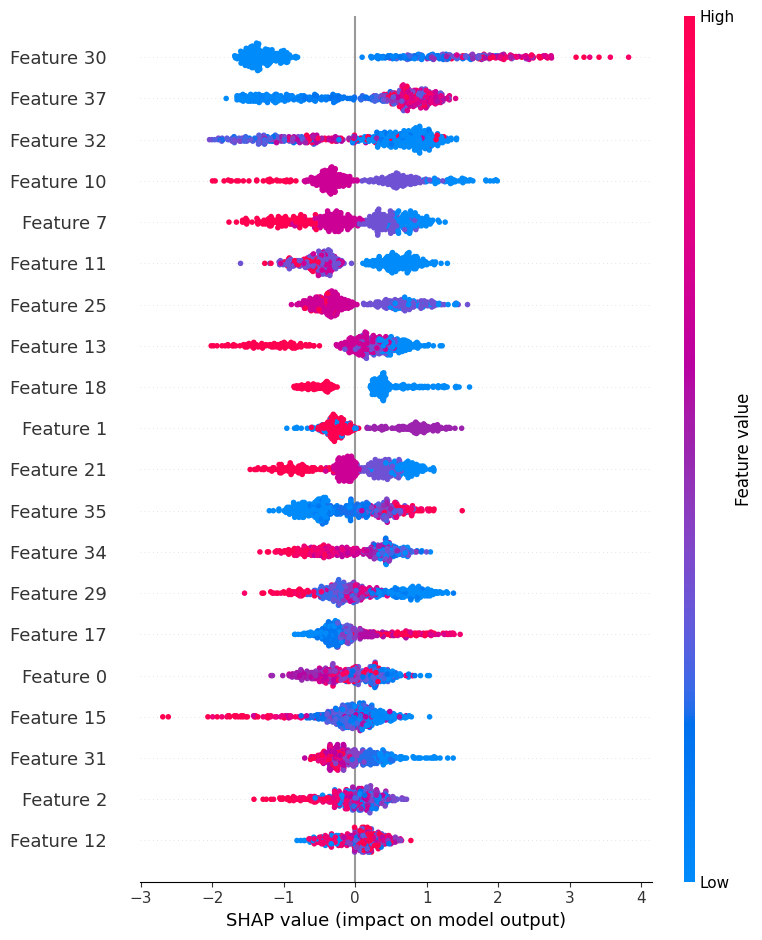

In [413]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [414]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

y_prob = best_model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy*100,2), "%")
print("Precision:", round(precision*100,2), "%")
print("Recall   :", round(recall*100,2), "%")
print("F1 Score :", round(f1*100,2), "%")
print("ROC-AUC  :", round(roc_auc*100,2), "%")

Accuracy : 94.13 %
Precision: 94.24 %
Recall   : 93.85 %
F1 Score : 94.05 %
ROC-AUC  : 97.87 %


Risk Score

In [415]:
y_prob = best_model.predict_proba(X_test)[:, 1]  

risk_df = pd.DataFrame()
risk_df['Risk Score'] = y_prob

def categorize_risk(score):
    if score < 0.4:
        return 'Low Risk'
    elif score < 0.7:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_df['Risk Category'] = risk_df['Risk Score'].apply(categorize_risk)

print(risk_df.head(10))
print("\nRisk Category Distribution:")
print(risk_df['Risk Category'].value_counts())

   Risk Score Risk Category
0    0.020694      Low Risk
1    0.021943      Low Risk
2    0.002442      Low Risk
3    0.999250     High Risk
4    0.998111     High Risk
5    0.999475     High Risk
6    0.994884     High Risk
7    0.934460     High Risk
8    0.032036      Low Risk
9    0.002023      Low Risk

Risk Category Distribution:
Risk Category
Low Risk       246
High Risk      228
Medium Risk     20
Name: count, dtype: int64


Prediction for a New Employee

In [ ]:
def predict_employee(employee_data: dict):
    """
    Pass employee details as a dictionary.
    Returns prediction, risk score, and risk category.
    """
    # Convert to DataFrame with same columns as training data
    emp_df = pd.DataFrame([employee_data])

    # Encode categorical columns using saved encoders
    for col in emp_df.select_dtypes(include='object').columns:
        if col in encoders:
            emp_df[col] = encoders[col].transform(emp_df[col])

    # Feature engineering (same as training)
    emp_df['OverTimeRisk']       = (emp_df['OverTime'] == 1).astype(int) * emp_df['DistanceFromHome']
    emp_df['SatisfactionIndex']  = emp_df['EnvironmentSatisfaction'] + emp_df['JobSatisfaction']
    emp_df['StockOptionWeight']  = emp_df['StockOptionLevel'] * emp_df['MonthlyIncome']
    emp_df['ExperienceGap']      = emp_df['TotalWorkingYears'] - emp_df['YearsAtCompany']
    emp_df['CareerStability']    = emp_df['YearsInCurrentRole'] / (emp_df['YearsAtCompany'] + 1)
    emp_df['CareerGrowthRisk']   = emp_df['YearsSinceLastPromotion'] / (emp_df['JobLevel'] + 1)
    emp_df['UnderPromotionRisk'] = emp_df['TotalWorkingYears'] / (emp_df['JobLevel'] + 1)
    emp_df['BurnoutRisk']        = emp_df['JobLevel'] * emp_df['OverTime'] * (emp_df['DistanceFromHome'] + 1)

    # Drop unused columns if present
    drop_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber', 'ExperienceCategory']
    emp_df = emp_df.drop(columns=[c for c in drop_cols if c in emp_df.columns])

    # Align columns with training data
    emp_df = emp_df.reindex(columns=X.columns, fill_value=0)

    # Scale
    emp_scaled = scaler.transform(emp_df)

    # Predict
    prediction  = best_model.predict(emp_scaled)[0]
    risk_score  = best_model.predict_proba(emp_scaled)[0][1]
    risk_label  = categorize_risk(risk_score)

    print(f"  Attrition Prediction : {'YES - Will Leave' if prediction == 1 else 'NO - Will Stay'}")
    print(f"  Risk Score           : {risk_score:.4f}")
    print(f"  Risk Category        : {risk_label}")

    return prediction, risk_score, risk_label


# Example Usage:
sample_employee = {
    'Age': 35,
    'BusinessTravel': 'Travel_Rarely',
    'DailyRate': 800,
    'Department': 'Sales',
    'DistanceFromHome': 10,
    'Education': 3,
    'EducationField': 'Life Sciences',
    'EnvironmentSatisfaction': 2,
    'Gender': 'Male',
    'HourlyRate': 60,
    'JobInvolvement': 3,
    'JobLevel': 2,
    'JobRole': 'Sales Executive',
    'JobSatisfaction': 2,
    'MaritalStatus': 'Single',
    'MonthlyIncome': 5000,
    'MonthlyRate': 14000,
    'NumCompaniesWorked': 3,
    'OverTime': 'Yes',
    'PercentSalaryHike': 11,
    'PerformanceRating': 3,
    'RelationshipSatisfaction': 2,
    'StockOptionLevel': 0,
    'TotalWorkingYears': 10,
    'TrainingTimesLastYear': 2,
    'WorkLifeBalance': 2,
    'YearsAtCompany': 4,
    'YearsInCurrentRole': 2,
    'YearsSinceLastPromotion': 3,
    'YearsWithCurrManager': 2
}

prediction, risk_score, risk_label = predict_employee(sample_employee)

  Attrition Prediction : YES - Will Leave
  Risk Score           : 0.9912
  Risk Category        : High Risk


Recommendation System

In [418]:
def generate_recommendations(employee_data: dict, risk_score: float, risk_label: str):
    """
    Generates personalized HR retention recommendations
    based on employee profile and risk level.
    """
    recommendations = []

    print(f"  HR RETENTION RECOMMENDATIONS")
    print(f"  Risk Level: {risk_label}  |  Score: {risk_score:.2f}")

    if risk_label == 'Low Risk':
        recommendations.append("✅ Employee is stable. Continue regular check-ins.")
        recommendations.append("📈 Offer growth opportunities to maintain engagement.")

    else:
        # 1. Overtime-related
        if employee_data.get('OverTime') == 'Yes':
            recommendations.append("Reduce overtime hours — high burnout risk detected.")
            recommendations.append("Consider flexible work hours or remote work options.")

        # 2. Salary-related
        if employee_data.get('MonthlyIncome', 0) < 5000:
            recommendations.append("Review and increase salary — below average compensation.")
            recommendations.append("Offer performance-based bonuses or incentives.")

        # 3. Job satisfaction
        if employee_data.get('JobSatisfaction', 3) <= 2:
            recommendations.append("Low job satisfaction detected — conduct 1-on-1 feedback sessions.")
            recommendations.append("Consider role rotation or new project assignments.")

        # 4. Work-life balance
        if employee_data.get('WorkLifeBalance', 3) <= 2:
            recommendations.append("Poor work-life balance — encourage leave utilization.")
            recommendations.append("Introduce employee wellness programs.")

        # 5. Promotion gap
        if employee_data.get('YearsSinceLastPromotion', 0) >= 3:
            recommendations.append("No promotion in 3+ years — evaluate for career advancement.")
            recommendations.append("Create a clear promotion roadmap with the employee.")

        # 6. Distance from home
        if employee_data.get('DistanceFromHome', 0) >= 20:
            recommendations.append("Long commute detected — offer work-from-home flexibility.")
            recommendations.append("Consider relocation allowance or transport support.")

        # 7. Environment satisfaction
        if employee_data.get('EnvironmentSatisfaction', 3) <= 2:
            recommendations.append("Low environment satisfaction — address workplace culture issues.")
            recommendations.append("Organize team-building and engagement activities.")

        # 8. Stock options
        if employee_data.get('StockOptionLevel', 0) == 0:
            recommendations.append("Offer stock options or equity benefits for retention.")

        # 9. Training
        if employee_data.get('TrainingTimesLastYear', 0) <= 1:
            recommendations.append("Provide more training & upskilling opportunities.")

        # 10. High risk final advice
        if risk_label == 'High Risk':
            recommendations.append("URGENT: Schedule immediate retention conversation with HR manager.")
            recommendations.append("Create a personalized retention plan within 30 days.")

    # Print all recommendations
    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. {rec}")

    return recommendations


# --- Run Prediction + Recommendations Together ---
def full_attrition_report(employee_data: dict):
    prediction, risk_score, risk_label = predict_employee(employee_data)
    recommendations = generate_recommendations(employee_data, risk_score, risk_label)
    return {
        'prediction': prediction,
        'risk_score': risk_score,
        'risk_label': risk_label,
        'recommendations': recommendations
    }

# Example
report = full_attrition_report(sample_employee)

  Attrition Prediction : YES - Will Leave
  Risk Score           : 0.9912
  Risk Category        : High Risk
  HR RETENTION RECOMMENDATIONS
  Risk Level: High Risk  |  Score: 0.99
  1. Reduce overtime hours — high burnout risk detected.
  2. Consider flexible work hours or remote work options.
  3. Low job satisfaction detected — conduct 1-on-1 feedback sessions.
  4. Consider role rotation or new project assignments.
  5. Poor work-life balance — encourage leave utilization.
  6. Introduce employee wellness programs.
  7. No promotion in 3+ years — evaluate for career advancement.
  8. Create a clear promotion roadmap with the employee.
  9. Low environment satisfaction — address workplace culture issues.
  10. Organize team-building and engagement activities.
  11. Offer stock options or equity benefits for retention.
  12. URGENT: Schedule immediate retention conversation with HR manager.
  13. Create a personalized retention plan within 30 days.


Deployment(Streamlit)

In [421]:
import joblib

joblib.dump(best_model, 'attrition_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

print("Model, Scaler, Encoders, and Columns saved successfully!")

Model, Scaler, Encoders, and Columns saved successfully!
